# Blood Cell Anomaly Detection

**Machine Learning Classification Project**

This project explores a blood-cell dataset and builds machine learning models to classify cells as:

- **0 → Normal**
- **1 → Abnormal**

The workflow covers data understanding, cleaning, encoding, outlier inspection, exploratory data analysis, preprocessing, model training, evaluation, and model comparison.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## 2. Load the Dataset

In [2]:
df = pd.read_csv('blood_cell_anomaly_detection.csv')

In [3]:
df.head(5)

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [4]:
df.shape

(5880, 36)

In [5]:
df.describe()

,anomaly_label,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,...,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,...,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.319728,10.176267,43.537976,0.391394,0.564173,0.769263,0.365458,1.882109,1.769252,0.842866,...,13.547194,41.021956,249792.623469,88.942211,33.495867,76.006803,336.235374,0.317583,0.853243,0.866370
std,0.466411,3.642051,33.419390,0.310006,0.335282,0.158219,0.201501,1.428336,1.229362,0.096033,...,2.025136,5.484636,79472.676228,9.927005,1.480168,25.032178,111.922015,0.349655,0.106589,0.094065
min,0.000000,1.000000,0.000000,0.000000,0.050000,0.100000,0.000000,0.000000,1.000000,0.290000,...,5.400000,20.300000,20000.000000,60.000000,28.000000,40.000000,224.000000,0.000000,0.417300,0.471700
25%,0.000000,7.630000,0.000000,0.000000,0.276000,0.711000,0.214750,0.670000,1.000000,0.784000,...,12.200000,37.300000,194653.250000,82.300000,32.500000,60.000000,224.000000,0.063675,0.799000,0.817250
50%,0.000000,10.055000,54.500000,0.479500,0.452000,0.805000,0.331000,1.320000,1.000000,0.854000,...,13.500000,41.000000,250070.500000,88.900000,33.500000,100.000000,256.000000,0.113150,0.877450,0.883400
75%,1.000000,12.860000,72.300000,0.635000,1.000000,0.879000,0.456000,2.980000,2.300000,0.918000,...,14.900000,44.800000,303863.500000,95.700000,34.500000,100.000000,360.000000,0.743850,0.929350,0.934000
max,1.000000,21.180000,99.000000,1.000000,1.000000,1.000000,0.990000,6.000000,7.200000,1.000000,...,20.000000,60.000000,543084.000000,120.000000,38.000000,100.000000,512.000000,1.000000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   cell_id                                  5880 non-null   str    
 1   cell_type                                5880 non-null   str    
 2   anomaly_label                            5880 non-null   int64  
 3   disease_category                         5880 non-null   str    
 4   cell_diameter_um                         5880 non-null   float64
 5   nucleus_area_pct                         5880 non-null   float64
 6   chromatin_density                        5880 non-null   float64
 7   cytoplasm_ratio                          5880 non-null   float64
 8   circularity                              5880 non-null   float64
 9   eccentricity                             5880 non-null   float64
 10  granularity_score                        5880 non-null   fl

## 3. Data Quality Checks

First, check for missing values and duplicated rows.

In [7]:
df.isnull().sum()

cell_id                                    0
cell_type                                  0
anomaly_label                              0
disease_category                           0
cell_diameter_um                           0
nucleus_area_pct                           0
chromatin_density                          0
cytoplasm_ratio                            0
circularity                                0
eccentricity                               0
granularity_score                          0
lobularity_score                           0
membrane_smoothness                        0
cell_area_px                               0
perimeter_px                               0
mean_r                                     0
mean_g                                     0
mean_b                                     0
stain_intensity                            0
patient_age_group                          0
patient_sex                                0
wbc_count_per_ul                           0
rbc_count_

In [8]:
df.duplicated().sum()

np.int64(0)

## 4. Target Distribution

Check the distribution of the target variable `anomaly_label`.

In [9]:
df['anomaly_label'].value_counts()

anomaly_label
0    4000
1    1880
Name: count, dtype: int64

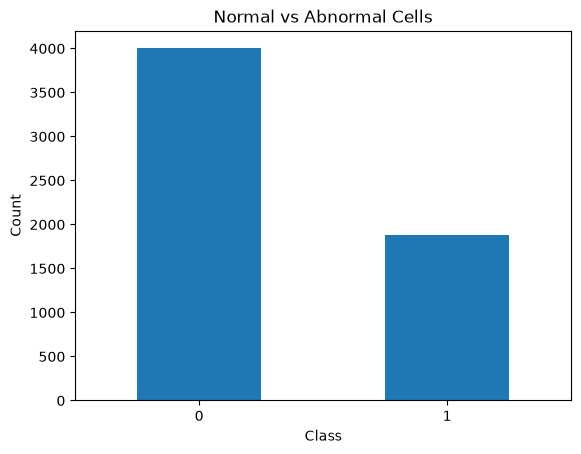

In [10]:
df['anomaly_label'].value_counts().plot(kind='bar')

plt.title('Normal vs Abnormal Cells')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 5. Feature Selection and Data Cleaning

The following columns are removed before modeling:

- `cell_id`: identifier only.
- `disease_category`: directly determines the target in this dataset, so it would cause target leakage.
- `cell_type`: categorical cell-type information was excluded from this modeling workflow.
- `dataset_source`, `staining_protocol`, `microscope_model`: dataset/collection metadata excluded from the model.
- `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`: anomaly-related derived information that can leak target information.
- `labeller_confidence_score`: annotation metadata rather than a predictive cell feature.

In [11]:
df = df.drop(columns=[
    'cell_id',
    'disease_category',
    'cell_type',
    'dataset_source',
    'staining_protocol',
    'microscope_model',
    'cytodiffusion_anomaly_score',
    'cytodiffusion_classification_confidence',
    'labeller_confidence_score'
])

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   anomaly_label              5880 non-null   int64  
 1   cell_diameter_um           5880 non-null   float64
 2   nucleus_area_pct           5880 non-null   float64
 3   chromatin_density          5880 non-null   float64
 4   cytoplasm_ratio            5880 non-null   float64
 5   circularity                5880 non-null   float64
 6   eccentricity               5880 non-null   float64
 7   granularity_score          5880 non-null   float64
 8   lobularity_score           5880 non-null   float64
 9   membrane_smoothness        5880 non-null   float64
 10  cell_area_px               5880 non-null   int64  
 11  perimeter_px               5880 non-null   int64  
 12  mean_r                     5880 non-null   int64  
 13  mean_g                     5880 non-null   int64  
 14  mea

## 6. Encode Categorical Features

`patient_sex` is binary, while `patient_age_group` has a natural age order.

In [13]:
print(df['patient_age_group'].unique())
print(df['patient_sex'].unique())

<StringArray>
['Elderly', 'Adult', 'Pediatric']
Length: 3, dtype: str
<StringArray>
['F', 'M']
Length: 2, dtype: str


In [14]:
df['patient_sex'] = df['patient_sex'].map({
    'M': 0,
    'F': 1
})

df['patient_age_group'] = df['patient_age_group'].map({
    'Pediatric': 0,
    'Adult': 1,
    'Elderly': 2
})

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   anomaly_label              5880 non-null   int64  
 1   cell_diameter_um           5880 non-null   float64
 2   nucleus_area_pct           5880 non-null   float64
 3   chromatin_density          5880 non-null   float64
 4   cytoplasm_ratio            5880 non-null   float64
 5   circularity                5880 non-null   float64
 6   eccentricity               5880 non-null   float64
 7   granularity_score          5880 non-null   float64
 8   lobularity_score           5880 non-null   float64
 9   membrane_smoothness        5880 non-null   float64
 10  cell_area_px               5880 non-null   int64  
 11  perimeter_px               5880 non-null   int64  
 12  mean_r                     5880 non-null   int64  
 13  mean_g                     5880 non-null   int64  
 14  mea

In [16]:
df.isna().sum()

anomaly_label                0
cell_diameter_um             0
nucleus_area_pct             0
chromatin_density            0
cytoplasm_ratio              0
circularity                  0
eccentricity                 0
granularity_score            0
lobularity_score             0
membrane_smoothness          0
cell_area_px                 0
perimeter_px                 0
mean_r                       0
mean_g                       0
mean_b                       0
stain_intensity              0
patient_age_group            0
patient_sex                  0
wbc_count_per_ul             0
rbc_count_millions_per_ul    0
hemoglobin_g_dl              0
hematocrit_pct               0
platelet_count_per_ul        0
mcv_fl                       0
mchc_g_dl                    0
magnification_x              0
image_resolution_px          0
dtype: int64

## 7. Outlier Inspection

Outliers are inspected rather than automatically removed. In this dataset, extreme blood-count values may represent real observations, so rows are retained.

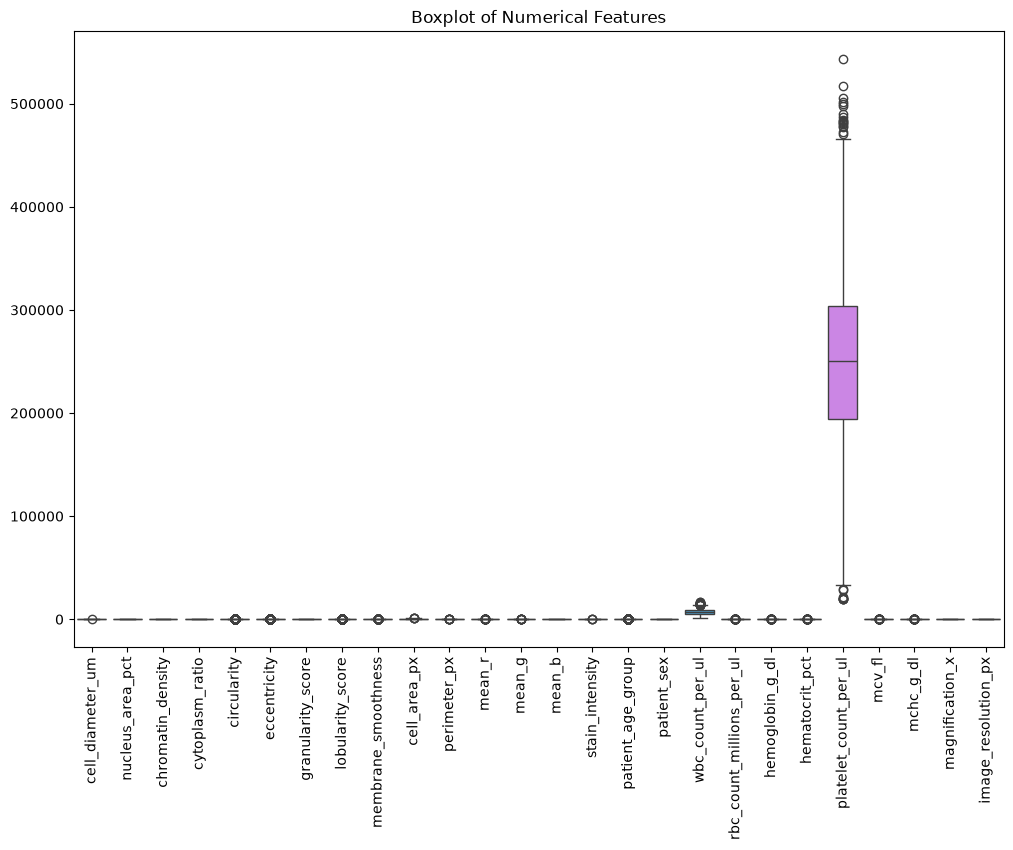

In [17]:
numeric_cols = df.drop(columns=['anomaly_label']).select_dtypes(
    include=['int64', 'float64']
).columns

plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title('Boxplot of Numerical Features')
plt.show()

In [18]:
df[['platelet_count_per_ul', 'wbc_count_per_ul']].describe()

,platelet_count_per_ul,wbc_count_per_ul
count,5880.000000,5880.000000
mean,249792.623469,7043.273980
std,79472.676228,2481.999916
min,20000.000000,1000.000000
25%,194653.250000,5371.750000
50%,250070.500000,7061.000000
75%,303863.500000,8727.500000
max,543084.000000,16855.000000


### Outlier Decision

The blood-count variables show some extreme observations, but the mean and median are relatively close. Therefore, no rows are removed and no log transformation is applied in this workflow.

## 8. Correlation Analysis

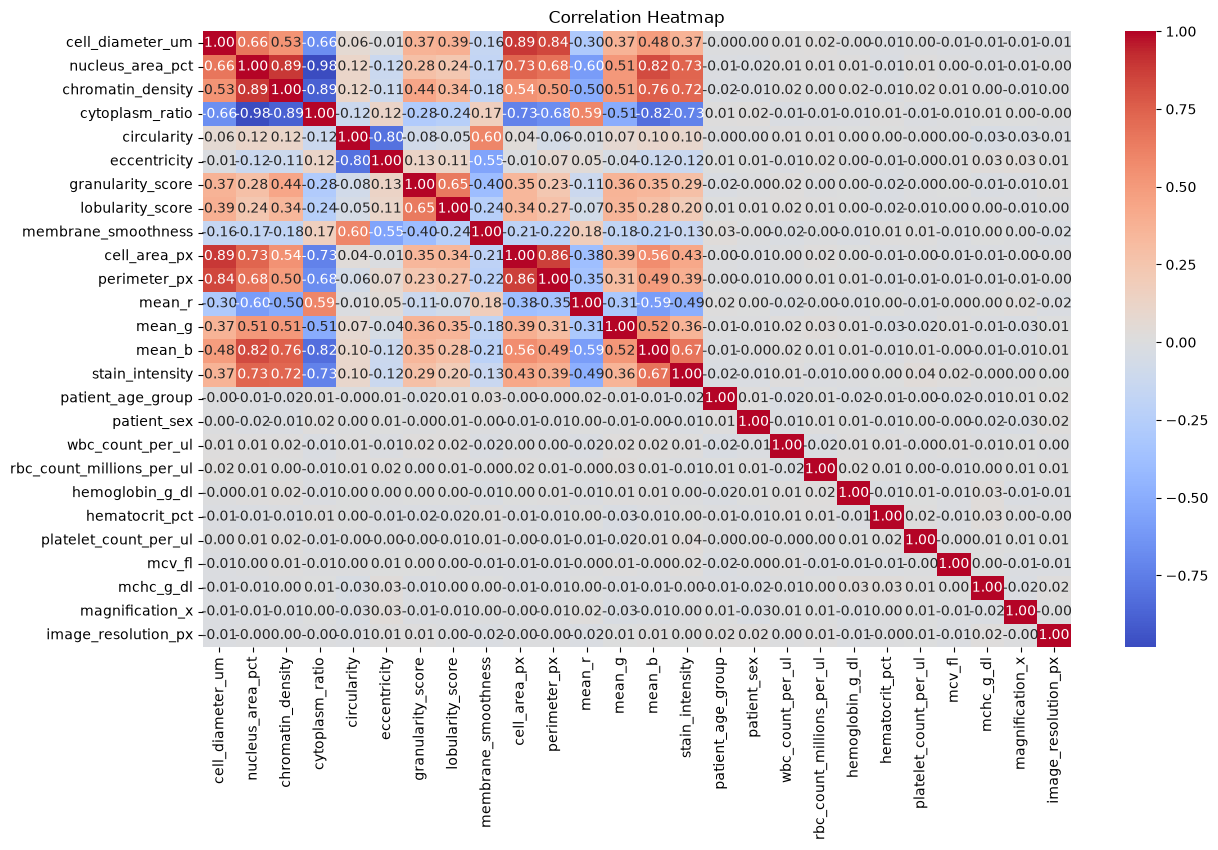

In [19]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

## 9. Prepare Features and Target

In [20]:
X = df.drop(columns=['anomaly_label'])
y = df['anomaly_label']

## 10. Train-Test Split

A stratified split is used so that the class distribution remains approximately consistent between training and testing sets.

In [21]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 11. Feature Scaling

`StandardScaler` is fitted only on the training data and then applied to both training and test data. This prevents information from the test set from influencing the scaling parameters.

In [22]:
scaler = StandardScaler()

scaler.fit(x_train)

scaled_x_train = scaler.transform(x_train)
scaled_x_test = scaler.transform(x_test)

## 12. Random Forest Classifier

In [23]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(scaled_x_train, y_train)

random_forest_predictions = random_forest_model.predict(scaled_x_test)

In [24]:
print("Confusion Matrix:")
random_forest_cm = confusion_matrix(y_test, random_forest_predictions)
print(random_forest_cm)

print("\nAccuracy:", accuracy_score(y_test, random_forest_predictions))
print("\nClassification Report:")
print(classification_report(y_test, random_forest_predictions))

Confusion Matrix:
[[796   4]
 [ 32 344]]

Accuracy: 0.9693877551020408

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       800
           1       0.99      0.91      0.95       376

    accuracy                           0.97      1176
   macro avg       0.97      0.95      0.96      1176
weighted avg       0.97      0.97      0.97      1176



## 13. Logistic Regression

In [25]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(scaled_x_train, y_train)

y_pred_logistic = logistic_model.predict(scaled_x_test)

In [26]:
print('Accuracy:', accuracy_score(y_test, y_pred_logistic))
print('Classification Report:')
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.8443877551020408
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       800
           1       0.84      0.64      0.72       376

    accuracy                           0.84      1176
   macro avg       0.84      0.79      0.81      1176
weighted avg       0.84      0.84      0.84      1176



## 14. Decision Tree Classifier

In [27]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(scaled_x_train, y_train)

y_pred_dt = dt_model.predict(scaled_x_test)

In [28]:
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Classification Report:')
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9260204081632653
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       800
           1       0.88      0.90      0.89       376

    accuracy                           0.93      1176
   macro avg       0.91      0.92      0.92      1176
weighted avg       0.93      0.93      0.93      1176



## 15. AdaBoost Classifier

In [29]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(scaled_x_train, y_train)

y_pred_ada = ada_model.predict(scaled_x_test)

In [30]:
print('Accuracy:', accuracy_score(y_test, y_pred_ada))
print('Classification Report:')
print(classification_report(y_test, y_pred_ada))

Accuracy: 0.9005102040816326
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       800
           1       0.93      0.74      0.83       376

    accuracy                           0.90      1176
   macro avg       0.91      0.86      0.88      1176
weighted avg       0.90      0.90      0.90      1176



## 16. Gradient Boosting Classifier

In [31]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(scaled_x_train, y_train)

y_pred_gb = gb_model.predict(scaled_x_test)

In [32]:
print('Accuracy:', accuracy_score(y_test, y_pred_gb))
print('Classification Report:')
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.967687074829932
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       800
           1       0.99      0.91      0.95       376

    accuracy                           0.97      1176
   macro avg       0.97      0.95      0.96      1176
weighted avg       0.97      0.97      0.97      1176



## 17. Support Vector Machine (SVM)

In [33]:
svm_model = SVC()

svm_model.fit(scaled_x_train, y_train)

y_pred_svm = svm_model.predict(scaled_x_test)

In [34]:
print('Accuracy:', accuracy_score(y_test, y_pred_svm))
print('Classification Report:')
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9209183673469388
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       800
           1       1.00      0.76      0.86       376

    accuracy                           0.92      1176
   macro avg       0.95      0.88      0.90      1176
weighted avg       0.93      0.92      0.92      1176



## 18. Gaussian Naive Bayes

In [35]:
nb_model = GaussianNB()

nb_model.fit(scaled_x_train, y_train)

y_pred_nb = nb_model.predict(scaled_x_test)

In [36]:
print('Accuracy:', accuracy_score(y_test, y_pred_nb))
print('Classification Report:')
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.7789115646258503
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       800
           1       0.71      0.52      0.60       376

    accuracy                           0.78      1176
   macro avg       0.76      0.71      0.72      1176
weighted avg       0.77      0.78      0.77      1176



## 19. K-Nearest Neighbors (KNN)

In [37]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(scaled_x_train, y_train)

y_pred_knn = knn_model.predict(scaled_x_test)

In [38]:
print('Accuracy:', accuracy_score(y_test, y_pred_knn))
print('Classification Report:')
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.9090136054421769
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       800
           1       0.96      0.75      0.84       376

    accuracy                           0.91      1176
   macro avg       0.93      0.87      0.89      1176
weighted avg       0.91      0.91      0.91      1176



## 20. XGBoost Classifier

In [39]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(scaled_x_train, y_train)

y_pred_xgb = xgb_model.predict(scaled_x_test)

In [40]:
print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Classification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9787414965986394
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       800
           1       0.99      0.95      0.97       376

    accuracy                           0.98      1176
   macro avg       0.98      0.97      0.98      1176
weighted avg       0.98      0.98      0.98      1176



## 21. Model Comparison

In [41]:
models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_dt,
    "Random Forest": random_forest_predictions,
    "AdaBoost": y_pred_ada,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb
}

results = []

for name, predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results).sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.9787,0.9861,0.9468,0.9661
1,Random Forest,0.9694,0.9885,0.9149,0.9503
2,Gradient Boosting,0.9677,0.9913,0.9069,0.9472
3,Decision Tree,0.9260,0.8753,0.8963,0.8857
4,SVM,0.9209,0.9965,0.7553,0.8593
5,KNN,0.9090,0.9590,0.7473,0.8401
6,AdaBoost,0.9005,0.9331,0.7420,0.8267
7,Logistic Regression,0.8444,0.8386,0.6356,0.7231
8,Naive Bayes,0.7789,0.7117,0.5186,0.6000


## 22. Conclusion

The project compared nine classification algorithms using the same train/test split. Evaluation included **accuracy, precision, recall, F1-score, and confusion matrix**.

The final comparison table summarizes the models' performance on the held-out test set. The selected preprocessing also avoids using identifier, annotation, and target-derived information as predictive features.

> **Note:** Model performance is specific to this dataset and test split and should not be interpreted as clinical performance.